In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt

from src.constants import DEVICE
from src.utils.set_random_seed import set_random_seed
from src.models.tools.get_classification_model import get_classification_model
from src.config_presets.tools.get_config import get_config
from src.config_presets.tools.load_config import load_config
from src.dataset.load_dataset import load_dataset
from src.dataset.get_dataloader import make_dataloader   
from src.dataset.get_transforms import get_transforms
from src.visualization.plot_slices import plot_slices


In [15]:
plot_slices_dicts = []

def plot_attention_methods(attn_array, attn_method_name, data, slice_indices=[60, 65, 70, 75, 80, 90]):
    inputs = data['input']
    #print(inputs.shape)
    try:
        CT = inputs[0]
        RTDOSE = inputs[1]
        RTSTRUCT = inputs[2]
    except:
        CT = inputs[0]
        RTDOSE = None
        RTSTRUCT = None
    
    n_channels = attn_array.shape[0] if len(attn_array.shape) > 3 else 1

    if attn_method_name.split(" ")[0] in ["GradCam", "GradCam++", "GuidedGradCam", "IntegratedGradients", "Deconvolution"] and n_channels == 1:
        method_dict = [{
            "Label": attn_method_name,
            'CT': CT * 600 - 200,
            # "RTDOSE"  : RTDOSE,
            # "RTSTRUCT" : RTSTRUCT,
            "Attention" : attn_array
        }]
    else:
        method_dict = [{
            "Label": attn_method_name,
            'CT': CT * 600 - 200,
            # "RTDOSE"  : RTDOSE,
            # "RTSTRUCT" : RTSTRUCT,
        }]
        for j in range(n_channels):
            method_dict.append({
                "Label": attn_method_name,
                'CT': CT * 600 - 200,
                #"RTDOSE"  : RTDOSE,
                "Attention" : attn_array[j]
            })
        #plot_slices_dicts.append(method_dict)

    fig, axes = plot_slices(method_dict, slice_indexes=slice_indices, title=None)
    
    return fig, axes
    


In [16]:

config_dir = os.path.join(r"C:\Users\S.P.M. de Vette\OneDrive - UMCG\Desktop\pred_RT_results\CT_artefact\ResNet10\KFold1","DlModel_Config.yaml")

# select if the config file is loaded with path or global
config = load_config(config_dir) #get_config('DETOXLung_config')

# Disable randomness
set_random_seed(config['general']['seed'])

# load data
df_train_val, df_test = load_dataset(config)
train_transforms, val_transforms = get_transforms(config)
test_loader, metadata = make_dataloader(config, df_test, val_transforms, validation_mode=True)


C:\Users\S.P.M. de Vette\OneDrive - UMCG\Desktop\pred_RT_results\CT_artefact\ResNet10\KFold1\DlModel_Config.yaml
Removed patients (no image data) = 0
Train/Val dataset 872 (80.0%), Test dataset 218 (20.0%)


In [17]:
attn_maps_root_dir = r"C:\Users\S.P.M. de Vette\OneDrive - UMCG\Desktop\att_maps\CT_artefact"
attn_maps_plotting_dir = r"C:\Users\S.P.M. de Vette\OneDrive - UMCG\Desktop\att_map_plots\CT_artefact"  # CT_artefact # Xerostomia_M06_2 # Xerostomia_M06

patient_folders = os.listdir(attn_maps_root_dir)


methods = ['GradCAM', 'GradCAM++', 'GuidedGradCAM', 'IntegratedGradients']
methods = ["Deconvolution"]

In [20]:
# plot the three different methods, from the same fold
from tqdm import tqdm
attn_method_names = []
attn_arrays = []

for patient_foldername in tqdm(patient_folders):
    patient_folder = os.path.join(attn_maps_root_dir, patient_foldername)
    attn_maps = os.listdir(patient_folder)

    patient_label, patient_id = patient_foldername.split('_')

    data = test_loader.get_patient(patient_id)

    if patient_label == "-1":
        patient_label = "1"
    #print(patient_label)
    # if patient_label == '1':
    #    continue
    for attn_map_filename in attn_maps:
        try:
            fold_n, pred, attn_method, layer = os.path.splitext(attn_map_filename)[0].split('_')
        except:
            fold_n, pred, attn_method = os.path.splitext(attn_map_filename)[0].split('_')
            layer = "standard"

        if attn_method not in methods:
            continue
        attn_map_path = os.path.join(patient_folder, attn_map_filename)

        figure_out_folder_dir = os.path.join(attn_maps_plotting_dir, patient_foldername)
        os.makedirs(figure_out_folder_dir, exist_ok=True)
        figure_out_filename = f"{os.path.splitext(attn_map_filename)[0]}.png"
        #plot_slices(attn_map_path, save_path=None, show=True)
        #print(attn_map_path)
        #print(fold_n, pred, attn_method, layer)

        

        # if fold_n == 'Fold0':

        #     att_array = np.load(attn_map_path)
            
        #     if (attn_method == 'GradCam++' or attn_method=="GradCam"): #and layer == 'block1':
        #         att_array = np.load(attn_map_path)
        #         print(att_array.shape)
        #         attn_arrays.append(att_array)
        #         attn_method_names.append(f"{attn_method} {layer}")

        #         print(patient_folder)

        #     elif ( attn_method == "GuidedGradCam") and layer == 'block1':
        #         att_array = np.load(attn_map_path)
        #         print(att_array.shape)
        #         attn_arrays.append(att_array)
        #         attn_method_names.append(f"{attn_method} {layer}")
            
        #     elif attn_method == 'IntegratedGradients' and layer == 'zeros':  # zeros  # randn
        #         #print(att_array.shape)
        #         print(attn_map_filename)
        #         att_array = np.load(attn_map_path)
        #         attn_arrays.append(att_array)
        #         attn_method_names.append(f"{attn_method} {layer}")

        #     else:
        #         continue






        att_array = np.load(attn_map_path)

        #print(att_array.shape)

        #print(figure_out_folder_dir)

        #print(f"{attn_method} {layer}")
        fig, axes = plot_attention_methods(att_array, f"{attn_method} {layer}", data, slice_indices=[60, 65, 70, 75, 80, 90])

        fig.savefig(os.path.join(figure_out_folder_dir, figure_out_filename), bbox_inches='tight')

        plt.close(fig)
        plt.clf()
        plt.cla()
        plt.close('all')





100%|██████████| 218/218 [03:58<00:00,  1.09s/it]


Fold0_0.95_IntegratedGradients_zeros.npy
IntegratedGradients zeros


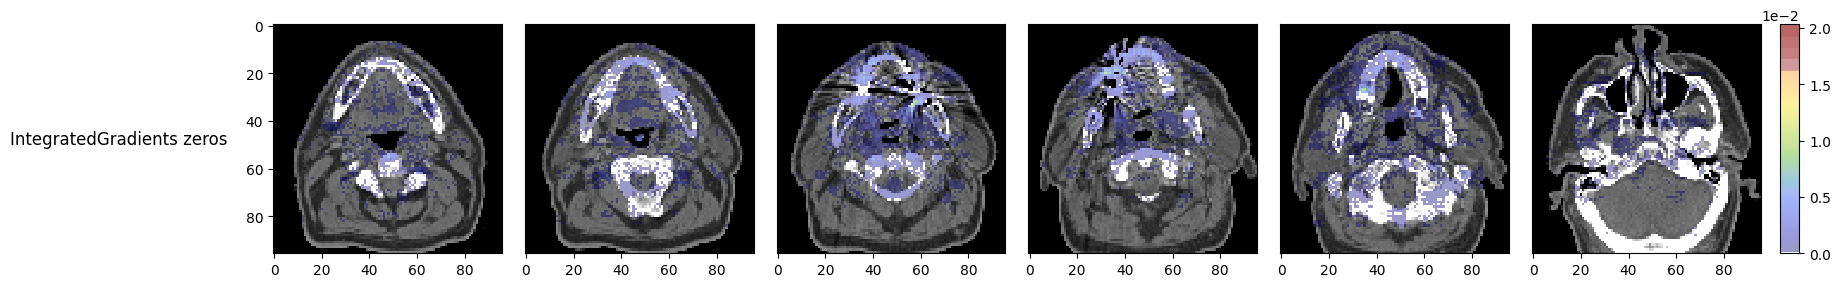

In [ ]:
# # plot the three different methods, from the same fold

# attn_method_names = []
# attn_arrays = []

# for patient_foldername in patient_folders:
#     patient_folder = os.path.join(attn_maps_root_dir, patient_foldername)
#     attn_maps = os.listdir(patient_folder)

#     patient_label, patient_id = patient_foldername.split('_')

#     data = test_loader.get_patient(patient_id)

#     if patient_label == "-1":
#         patient_label = "1"
#     #print(patient_label)
#     if patient_label == '0':
#         continue
#     for attn_map_filename in attn_maps:
#         fold_n, pred, attn_method, layer = os.path.splitext(attn_map_filename)[0].split('_')
#         attn_map_path = os.path.join(patient_folder, attn_map_filename)

#         figure_out_folder_dir = os.path.join(attn_maps_plotting_dir, patient_foldername)
#         figure_out_filename = f"{os.path.splitext(attn_map_filename)[0]}.png"
#         #plot_slices(attn_map_path, save_path=None, show=True)
#         #print(attn_map_path)
#         #print(fold_n, pred, attn_method, layer)

#         if fold_n == 'Fold0':

#             att_array = np.load(attn_map_path)
            
#             if (attn_method == 'GradCam++' or attn_method=="GradCam"): #and layer == 'block1':
#                 att_array = np.load(attn_map_path)
#                 print(att_array.shape)
#                 attn_arrays.append(att_array)
#                 attn_method_names.append(f"{attn_method} {layer}")

#                 print(patient_folder)

#             elif ( attn_method == "GuidedGradCam") and layer == 'block1':
#                 att_array = np.load(attn_map_path)
#                 print(att_array.shape)
#                 attn_arrays.append(att_array)
#                 attn_method_names.append(f"{attn_method} {layer}")
            
#             elif attn_method == 'IntegratedGradients' and layer == 'zeros':  # zeros  # randn
#                 #print(att_array.shape)
#                 print(attn_map_filename)
#                 att_array = np.load(attn_map_path)
#                 attn_arrays.append(att_array)
#                 attn_method_names.append(f"{attn_method} {layer}")

#             else:
#                 continue

#             print(f"{attn_method} {layer}")
#             fig, axes = plot_attention_methods(att_array, f"{attn_method} {layer}", data, slice_indices=[60, 65, 70, 75, 80, 90])

#             plt.show()

#     break




In [199]:
data = test_loader.get_patient(patient_id)

inputs = data['input']




In [192]:
attn_array.shape

(3, 96, 96, 96)

In [169]:
attn_arrays[0].shape

(96, 96, 96)

In [161]:
attn_method, layer, patient_id, fold_n

('IntegratedGradients', 'zeros', '0625979', 'Fold4')

In [152]:
attn_method

'IntegratedGradients'

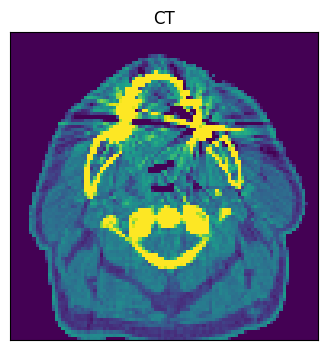

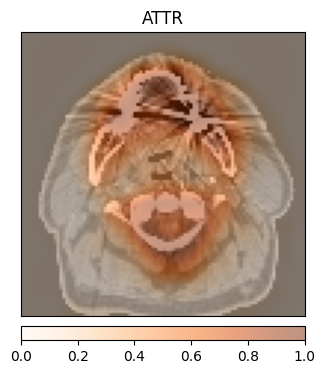

(<Figure size 400x400 with 2 Axes>, <Axes: title={'center': 'ATTR'}>)

In [216]:
from captum.attr import visualization as viz
import torch


captum_CT = CT[70].numpy().reshape(96, 96, 1)
captum_attr = attn_arrays[0][70].reshape(96, 96, 1)

viz.visualize_image_attr(None, captum_CT, method="original_image",
                        title="CT",fig_size=(4,4))
viz.visualize_image_attr(captum_attr, captum_CT, plt_fig_axis=None, method="blended_heat_map",
                         show_colorbar=True, cmap="Oranges", title="ATTR", fig_size=(4,4))

In [ ]:
# plot the three different methods, from the same fold

attn_method_names = []
attn_arrays = []

for patient_foldername in patient_folders:
    patient_folder = os.path.join(attn_maps_root_dir, patient_foldername)
    attn_maps = os.listdir(patient_folder)

    patient_label, patient_id = patient_foldername.split('_')

    if patient_label == "-1":
        patient_label = "1"
    #print(patient_label)
    if patient_label == '0':
        continue
    for attn_map in attn_maps:
        fold_n, pred, attn_method, layer = os.path.splitext(attn_map)[0].split('_')
        attn_map_path = os.path.join(patient_folder, attn_map)
        #plot_slices(attn_map_path, save_path=None, show=True)
        #print(attn_map_path)
        #print(fold_n, pred, attn_method, layer)

        if fold_n == 'Fold1':
            
            if (attn_method == 'GradCam++' or attn_method=="GradCam") and layer == 'block1':
                att_array = np.load(attn_map_path)
                print(att_array.shape)
                attn_arrays.append(att_array)
                attn_method_names.append(f"{attn_method} {layer}")

                print(patient_folder)

            elif ( attn_method == "GuidedGradCam") and layer == 'block1':
                att_array = np.load(attn_map_path)
                print(att_array.shape)
                attn_arrays.append(att_array)
                attn_method_names.append(f"{attn_method} {layer}")
            
            elif attn_method == 'IntegratedGradients' and layer == 'zeros':
                print(att_array.shape)
                attn_arrays.append(np.load(attn_map_path))
                attn_method_names.append(f"{attn_method} {layer}")

    break


